<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/Machine_Learning_Models_for_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"The rate of failure in quantitative finance is high, particularly so in Financial ML" (Marcos Lopez).

In [ ]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
import pandas_ta as ta
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [ ]:
# Import Data Using yfinance
df = yf.download(
    tickers = 'AAPL',
    start = '2016-01-01',
    end = '2026-03-01',
    interval = '1d',
)
df.head(5)


/tmp/ipykernel_38475/1097903125.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.730942,23.735448,22.976327,23.113735,270597600
2016-01-05,23.136269,23.843579,23.068692,23.821054,223164000
2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600
2016-01-08,21.841026,22.325332,21.795975,22.199188,283192000


In [ ]:
# Pre-Process Data
df.columns = df.columns.get_level_values(0)
df['Ticker'] = 'AAPL'
df = df.reset_index()
df.head(5)


Price,Date,Close,High,Low,Open,Volume,Ticker
0,2016-01-04,23.730942,23.735448,22.976327,23.113735,270597600,AAPL
1,2016-01-05,23.136269,23.843579,23.068692,23.821054,223164000,AAPL
2,2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600,AAPL
3,2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600,AAPL
4,2016-01-08,21.841026,22.325332,21.795975,22.199188,283192000,AAPL


Feature Engineering

In [ ]:
# SMA200
df['SMA200'] = df['Close'].rolling(window=200).mean()
# RSI14
df['RSI14'] = ta.rsi(df['Close'], window=14)
# Five Day Closing Percentage
df['5d_pct_change'] = df['Close'].pct_change(periods=5)
# Log Volume
df['log_volume'] = np.log(df['Volume'])
df.head(5)

Price,Date,Close,High,Low,Open,Volume,Ticker,SMA200,RSI14,5d_pct_change,log_volume
0,2016-01-04,23.730942,23.735448,22.976327,23.113735,270597600,AAPL,NaN,NaN,NaN,19.416143
1,2016-01-05,23.136269,23.843579,23.068692,23.821054,223164000,AAPL,NaN,0.000000,NaN,19.223417
2,2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600,AAPL,NaN,0.000000,NaN,19.428017
3,2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600,AAPL,NaN,0.000000,NaN,19.597419
4,2016-01-08,21.841026,22.325332,21.795975,22.199188,283192000,AAPL,NaN,1.425274,NaN,19.461636


Target Variable

In [ ]:
# Five Day Future Closing Percentage
df['5d_future_pct_change'] = df['Close'].pct_change(periods=5).shift(-5)
df=df.dropna()
df


Price,Date,Close,High,Low,Open,Volume,Ticker,SMA200,RSI14,5d_pct_change,log_volume,5d_future_pct_change
199,2016-10-17,26.929972,26.996407,26.753569,26.879571,94499600,AAPL,23.300883,69.082279,0.012926,18.364106,0.000851
200,2016-10-18,26.911646,27.081175,26.907063,27.074302,98214000,AAPL,23.316787,68.568232,0.010060,18.402659,0.006640
201,2016-10-19,26.831455,26.978075,26.070864,26.861237,80138400,AAPL,23.335263,66.245298,-0.001875,18.199266,-0.013063
202,2016-10-20,26.817715,26.891025,26.650477,26.771897,96503200,AAPL,23.355934,65.833744,0.000684,18.385087,-0.022040
203,2016-10-21,26.712332,26.783352,26.639022,26.760441,92770800,AAPL,23.380865,62.620528,-0.008756,18.345642,-0.024700
...,...,...,...,...,...,...,...,...,...,...,...,...
2543,2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700,AAPL,239.602382,39.585494,-0.079464,17.846040,0.040660
2544,2026-02-17,263.880005,266.290009,255.539993,258.049988,58469100,AAPL,239.863892,48.607349,-0.039109,17.884009,0.031302
2545,2026-02-18,264.350006,266.820007,262.450012,263.600006,34203300,AAPL,240.123671,49.082488,-0.034091,17.347833,0.037375
2546,2026-02-19,260.579987,264.480011,260.049988,262.600006,30845300,AAPL,240.404276,45.452492,-0.054156,17.244495,0.047471


Make Clean Modeling Dataset

In [ ]:
feature_cols = [
    'SMA200',
    'RSI14',
    '5d_pct_change',
    'log_volume'
]

target_col = '5d_future_pct_change'

model_df = df[feature_cols + [target_col]].dropna()
model_df.head(5)


Price,SMA200,RSI14,5d_pct_change,log_volume,5d_future_pct_change
199,23.300883,69.082279,0.012926,18.364106,0.000851
200,23.316787,68.568232,0.010060,18.402659,0.006640
201,23.335263,66.245298,-0.001875,18.199266,-0.013063
202,23.355934,65.833744,0.000684,18.385087,-0.022040
203,23.380865,62.620528,-0.008756,18.345642,-0.024700


Check Correlations Among Features and Target Variable

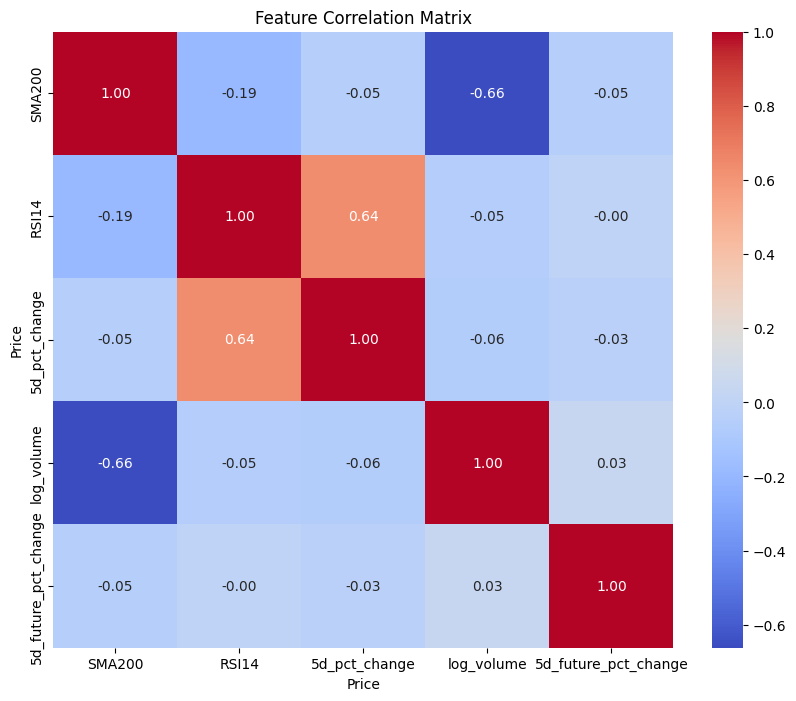

In [ ]:
corr = model_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

Note on weak correlations between features and target variable. Weak correlations are normal in financial markets because future returns are extremely noisy and close to random-walk behavior, so even real signals tend to have very small linear relationships with the target. This affirms that markets are nonlinear.

Modeling. Below are a list of Models that will be explored:
1.   Linear Regression Model
2.   Random Forest
3.   Gradient Boosting
4.   KNN Regression
5.   Neural Networks

Note: There are many more models and hybrid models that can be explored.


**Linear Regression**

In [ ]:
x = model_df[feature_cols] # feature matrix
y = model_df[target_col] # target vector

X = sm.add_constant(x)

train_size = int(0.7*len(x)) #70/30 train-test split
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Model data

model = sm.OLS(y_train, X_train)
results = model.fit()
print(f'In Sample R-Squared value: {results.rsquared}')

y_pred = results.predict(X_test)
from sklearn.metrics import r2_score
print("Out of Sample R-Squared: ", r2_score(y_test, y_pred))



In Sample R-Squared value: 0.004221024097427972
Out of Sample R-Squared:  -0.01336913259088246


Plot Actual vs Predicted Returns

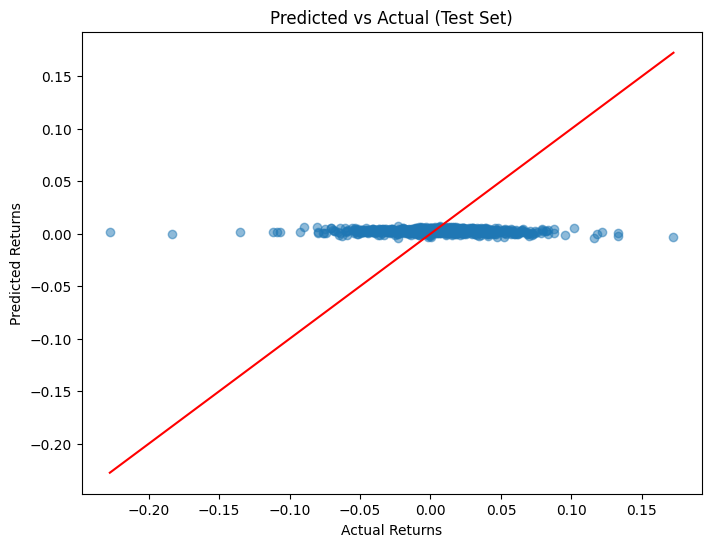

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Predicted vs Actual (Test Set)")

# 45-degree reference line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color = 'red')
plt.show()

The negative out-of-sample R^2 means the model is performing worse than simply predicting the average return every time. The scatter plot looks like a horizontal cloud around zero because the safest prediction for this model is to output values near zero. However, this behavior is completely normal in financial return prediction, since markets have very low signal-to-noise ratios and linear models often fail to capture the nonlinear, regime-dependent structure that may exist.

Directional Accuracy

In [ ]:
direction_pred = (y_pred > 0).astype(int)
direction_actual = (y_test > 0).astype(int)

print("Directional Accuracy:", (direction_pred == direction_actual).mean())

Directional Accuracy: 0.5333333333333333


**Random Forest**

Find Optimal Parameters

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

grid = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'max_features': [4, 8]
}

test_scores = []
for g in ParameterGrid(grid):
  rfr = RandomForestRegressor(random_state=42, **g)
  rfr.fit(X_train, y_train)
  test_scores.append(rfr.score(X_test, y_test))

best_idx = np.argmax(test_scores)
print(test_scores[best_idx])
print(ParameterGrid(grid)[best_idx])

-0.5514452984568319
{'n_estimators': 200, 'max_features': 4, 'max_depth': 3}


Model Using Optimal Parameters

In [ ]:
# Fit Model
rfr = RandomForestRegressor(n_estimators=200, max_depth=3, max_features=4, random_state=42)
rfr.fit(X_train, y_train)
print(f'In Sample R-Squared value: {rfr.score(X_train, y_train)}')
# Predict Using Fitted Model
y_pred = rfr.predict(X_test)
print("Out of Sample R-Squared: ", r2_score(y_test, y_pred))

In Sample R-Squared value: 0.08547150112611024
Out of Sample R-Squared:  -0.5514452984568319


Plot Predicted vs Actual

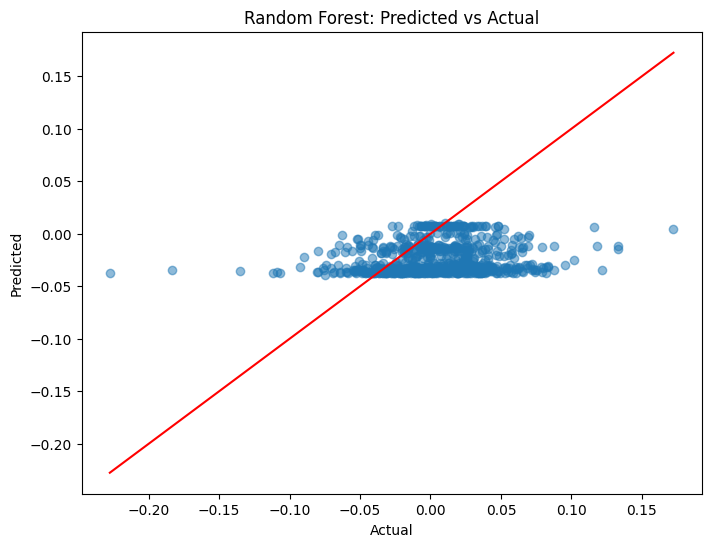

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

Feature Importances

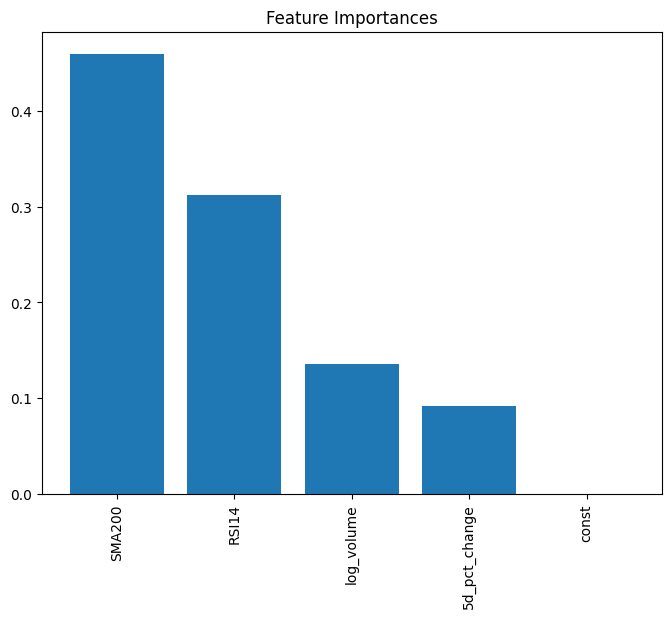

In [ ]:
importances = rfr.feature_importances_
sorted_index = np.argsort(importances)[::-1]
feature_array = np.array(X_train.columns)
plt.figure(figsize=(8,6))
plt.bar(
    range(len(importances)),
    importances[sorted_index],
    tick_label=feature_array[sorted_index]
)
plt.xticks(rotation=90)
plt.title("Feature Importances")
plt.show()

Directional Accuracy

In [ ]:
direction_pred = (y_pred > 0).astype(int)
direction_actual = (y_test > 0).astype(int)
print("Directional Accuracy: ", (direction_pred == direction_actual).mean())

Directional Accuracy:  0.5035460992907801


**Gradient Boosting**

Find Optimal Parameters

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01],
    'max_depth': [3, 5],
    'max_features': [1,2],
    'subsample': [0.6]
}

test_scores = []
for g in ParameterGrid(grid):
  gbr = GradientBoostingRegressor(random_state=42, **g)
  gbr.fit(X_train, y_train)
  test_scores.append(gbr.score(X_test, y_test))

best_idx = np.argmax(test_scores)
print(ParameterGrid(grid)[best_idx])

{'subsample': 0.6, 'n_estimators': 300, 'max_features': 1, 'max_depth': 3, 'learning_rate': 0.01}


Model Using Optimal Parameters

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
                        subsample=0.6,
                        n_estimators=300,
                        max_features=1,
                        max_depth=3,
                        learning_rate=0.01,
                        random_state=42
)
gbr.fit(X_train, y_train)
print(f'In Sample R-Squared value: {gbr.score(X_train, y_train)}')

y_pred = gbr.predict(X_test)
print("Out of Sample R-Squared: ", r2_score(y_test, y_pred))


In Sample R-Squared value: 0.14269171579270667
Out of Sample R-Squared:  -0.17994853550560586


Plot Predicted vs Actual

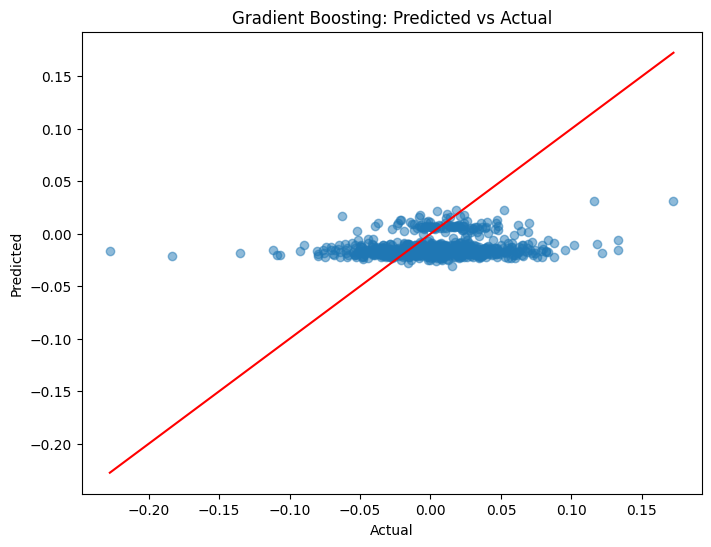

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting: Predicted vs Actual")
plt.show()

Directional Accuracy

In [ ]:
direction_pred = (y_pred > 0).astype(int)
direction_actual = (y_test > 0).astype(int)

print("Directional Accuracy: ", (direction_pred == direction_actual).mean())

Directional Accuracy:  0.5078014184397163


**KNN Regression**

Normalize Data; scaling options:
  - Min-Max
  - Standardization
  - Median-MAD
  - map of arbitrary function (sigmoid, tanh)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Optimize Nearest Neighbor

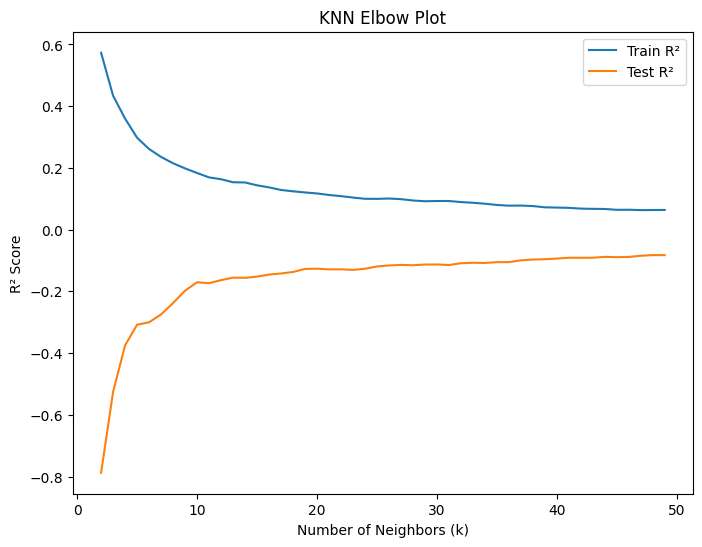

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

k_values = range(2,50)

train_scores = []
test_scores = []

for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)

  train_scores.append(knn.score(X_train_scaled, y_train))
  test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(8,6))

plt.plot(k_values, train_scores, label="Train R²")
plt.plot(k_values, test_scores, label="Test R²")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R² Score")
plt.title("KNN Elbow Plot")
plt.legend()
plt.show()


Model with Optimal K

In [ ]:
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

train_predictions = knn.predict(X_train_scaled)
test_predictions = knn.predict(X_test_scaled)

knn.score(X_test_scaled, y_test)
print(f"Out of Sample R-Squared: ", {knn.score(X_test_scaled, y_test)})


Out of Sample R-Squared:  {-0.17044696559861872}


Directional Accuracy

In [ ]:
direction_pred = (test_predictions > 0).astype(int)
direction_actual = (y_test > 0).astype(int)

print("Directional Accuracy: ", (direction_pred == direction_actual).mean())

Directional Accuracy:  0.5531914893617021


**Neural Network**

Train the Neural Network

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


val_frac = 0.15
n_train = X_train_scaled.shape[0]
val_start = int((1 - val_frac) * n_train)

X_tr = X_train_scaled[:val_start]
y_tr = y_train[:val_start]

X_val = X_train_scaled[val_start:]
y_val = y_train.iloc[val_start:]

# RMSE loss
def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4), input_shape=(X_tr.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(1, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=rmse_loss
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1338 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0709 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0619 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0486 - val_loss: 0.0485 - learning_rate: 0.0010
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0491 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0443 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0456 - val_loss: 0.0451 - learning_rate: 0.0010
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0420 - val_loss: 0.0448 - learning_rate: 0.0010
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0416 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 10/200
44/44 ━━━━━━━━━━━

Plot Loss Curves

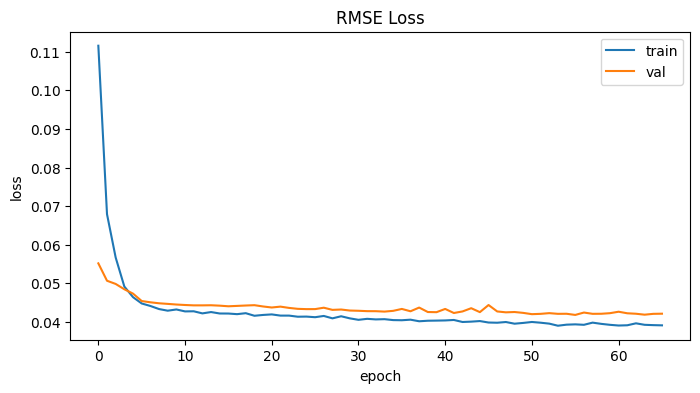

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("RMSE Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

Evaluate Neural Network

In [ ]:
pred_tr = model.predict(X_tr).ravel()
pred_val = model.predict(X_val).ravel()
pred_test = model.predict(X_test_scaled).ravel()

print("R² train:", r2_score(y_tr, pred_tr))
print("R² val:  ", r2_score(y_val, pred_val))
print("R² test: ", r2_score(y_test, pred_test))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
R² train: 0.06348761839867345
R² val:   0.05249382907403599
R² test:  -0.378052812049956


Predicted vs Actual

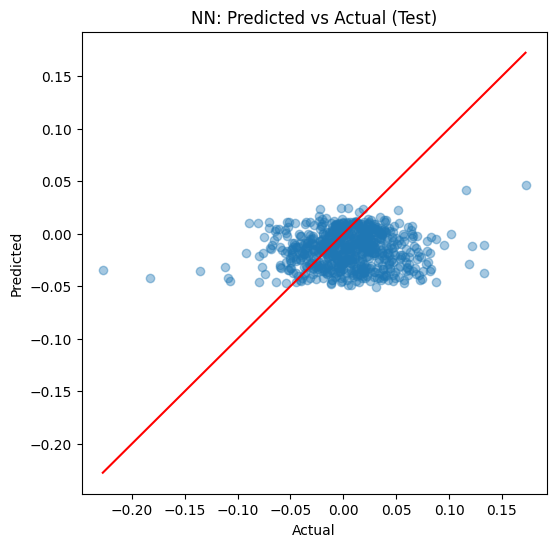

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.4)
mn = min(y_test.min(), pred_test.min())
mx = max(y_test.max(), pred_test.max())
plt.plot([mn, mx], [mn, mx], color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("NN: Predicted vs Actual (Test)")
plt.show()

Directional Accuracy

In [ ]:
direction_pred = (pred_test > 0).astype(int)
direction_actual = (y_test > 0).astype(int)

print("Directional Accuracy: ", (direction_pred == direction_actual).mean())

Directional Accuracy:  0.502127659574468


**Final Thoughts**
Across linear, tree-based, instance-based, and neural modes, out-of-sample R^2 remained negative. Although this is not an inherently bad thing, a couple things could be improved upon to help the predictive power of the ML models.

1.   Extremely low signal-to-noise ratio:
The target variable (future 5-day return) is small in magnitude and nosiy.
2.   Regime Instability:
Acorss ten years of market data there are multiple regime shifts that most likely happened, being able to identify and adapt to those can help model performance.
3.   Improve the Feature Set:
Features are basic, better features can lead to better models.
4.   Use Proper Time-Series Cross Validation
Rolling or walk-forward validation.
5. Overfitting:
Most of the times my in sample R-squared value was better than my out of sample R-squared value.